# Advanced Market Microstructure Bars Engine
**A Unified Factory for Standard and Information-Driven Financial Data Bars**

This repository provides a highly optimized, institutional-grade engine to transform raw tick data into structured bars commonly used in quantitative research and market microstructure analysis. 

### Key Engineering Features:
- **Lookahead Bias Prevention:** Utilizes precise timestamp grouping (`closed='right'`, `label='right'`).
- **High-Performance Aggregation:** Implements `Numba` JIT compilation to process massive arrays in O(N) time, properly resetting cumulative thresholds for information-driven bars.
- **Timezone Safety:** Handles CME session shifts (Chicago Timezone) accurately to prevent calendar-day splitting of continuous trading sessions.
- **Memory Efficiency:** Avoids deep copies where unnecessary and uses vectorized operations.

This engine supports **Time Bars**, **Daily Bars** (CME aligned), and Marcos López de Prado's **Information-Driven Bars** (Tick, Volume, Dollar Bars).

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from numba import njit
import warnings

warnings.filterwarnings('ignore')

## 1. Timezone Safety & Exchange Alignment
Standardizing raw timestamps. The `_to_chicago` function ensures naive timestamps are treated as UTC and converted to Chicago time, which is critical for correctly processing CME futures contract settlements.

In [2]:
def _to_chicago(ts: pd.Series) -> pd.Series:
    """
    Handles timezone-naive data by assuming UTC, then converts 
    it to America/Chicago time to accurately process futures settlements.
    """
    if ts.dt.tz is None:
        ts = ts.dt.tz_localize('UTC')
    return ts.dt.tz_convert('America/Chicago')

## 2. Standard Time Bars
Traditional time-based aggregation (e.g., 1min, 5min, 1H). The function is specifically engineered to prevent lookahead bias by labeling and closing bins on the right side of the interval. It also includes built-in Volume-Weighted Average Price (VWAP) calculations.

In [3]:
def generate_time_bars(df: pd.DataFrame, freq: str = '5min', price_col: str = 'price_adj') -> pd.DataFrame:
    """
    Aggregates tick data into standard time bars.
    """
    cols = ['datetime', price_col, 'size', 'dollar_value']
    d = df[cols].copy(deep=False)
    
    # Using label='right' and closed='right' strictly prevents future data leakage
    grouper = pd.Grouper(key='datetime', freq=freq, label='right', closed='right')
    g = d.groupby(grouper)
    
    bars = g[price_col].agg(['first', 'max', 'min', 'last'])
    bars.columns = ['open', 'high', 'low', 'close']
    bars['volume'] = g['size'].sum()
    bars['dollar_value'] = g['dollar_value'].sum()
    bars['n_ticks'] = g[price_col].count()
    
    # Calculate VWAP with division-by-zero protection
    bars['vwap'] = np.where(bars['volume'] > 0, bars['dollar_value'] / bars['volume'], np.nan)
    
    # Clean up empty intervals
    bars = bars[bars['close'].notna() & (bars['volume'] > 0)]
    bars.index.name = 'datetime_end'
    
    return bars.reset_index()

## 3. Session-Aligned Daily Bars (CME)
Standard daily grouping often splits the continuous electronic trading session. This function shifts the timeframe by +7 hours to aggregate a full CME session (5 PM to 4 PM next day) into a single, accurate daily bar.

In [4]:
def generate_daily_bars(df: pd.DataFrame, price_col: str = 'price_adj') -> pd.DataFrame:
    """
    Aggregates tick data into daily bars respecting the true exchange trading day.
    """
    cols = ['datetime', price_col, 'size', 'dollar_value']
    d = df[cols].copy(deep=False)
    
    # Shift time by +7 hours to group the CME session into a single calendar day
    d['_chicago_shifted'] = _to_chicago(d['datetime']) + pd.Timedelta(hours=7)
    
    grouper = pd.Grouper(key='_chicago_shifted', freq='1D', label='right', closed='right')
    g = d.groupby(grouper)
    
    bars = g[price_col].agg(['first', 'max', 'min', 'last'])
    bars.columns = ['open', 'high', 'low', 'close']
    bars['volume'] = g['size'].sum()
    bars['dollar_value'] = g['dollar_value'].sum()
    bars['n_ticks'] = g[price_col].count()
    
    bars['vwap'] = np.where(bars['volume'] > 0, bars['dollar_value'] / bars['volume'], np.nan)
    bars = bars[bars['close'].notna() & (bars['volume'] > 0)]
    
    # Reverse the shift to restore authentic UTC timestamps
    bars.index = (bars.index - pd.Timedelta(hours=7)).tz_convert('UTC')
    bars.index.name = 'datetime_end'
    
    return bars.reset_index()

## 4. Information-Driven Bars (Tick, Volume, Dollar)
Time bars often suffer from poor statistical properties (e.g., non-normality, heteroscedasticity). Information-driven bars sample the market based on activity. 

A critical engineering challenge here is looping through millions of rows to check cumulative thresholds. Using a pure Python `for` loop is too slow, and Pandas `cumsum` cannot reset dynamically. **Solution:** A highly optimized `Numba JIT` compiler function to track the cumulative sum and reset the counter with zero memory overhead.

In [5]:
@njit
def _compute_bar_ids(metric_values: np.ndarray, threshold: float) -> np.ndarray:
    """
    Fast Numba-compiled function to track cumulative sums and reset precisely 
    when the threshold is crossed. This is the structurally correct way to 
    ensure a constant amount of information per bar.
    """
    n = len(metric_values)
    bar_ids = np.zeros(n, dtype=np.int32)
    current_bar_id = 0
    cum_sum = 0.0
    
    for i in range(n):
        cum_sum += metric_values[i]
        bar_ids[i] = current_bar_id
        
        if cum_sum >= threshold:
            current_bar_id += 1
            cum_sum = 0.0  # Resetting the counter accurately
            
    return bar_ids

def generate_threshold_bars(df: pd.DataFrame, metric: str = 'dollar', threshold: float = 50_000, 
                            price_col: str = 'price_adj') -> pd.DataFrame:
    """
    Generates Tick, Volume, or Dollar bars based on a predefined threshold.
    """
    cols = ['datetime', price_col, 'size', 'dollar_value']
    d = df[cols].copy()
    
    # Select the metric to aggregate
    if metric == 'tick':
        metric_values = np.ones(len(d), dtype=np.float64)
    elif metric == 'volume':
        metric_values = d['size'].values.astype(np.float64)
    elif metric == 'dollar':
        metric_values = d['dollar_value'].values.astype(np.float64)
    else:
        raise ValueError("Metric must be 'tick', 'volume', or 'dollar'")
        
    # Apply Numba Engine
    d['bar_id'] = _compute_bar_ids(metric_values, float(threshold))
    
    # Aggregate based on the dynamically generated bar IDs
    bars = d.groupby('bar_id').agg(
        datetime_start=('datetime', 'first'),
        datetime_end=('datetime', 'last'),
        open=(price_col, 'first'),
        high=(price_col, 'max'),
        low=(price_col, 'min'),
        close=(price_col, 'last'),
        volume=('size', 'sum'),
        dollar_value=('dollar_value', 'sum'),
        n_ticks=(price_col, 'count'),
    )
    
    # Calculate VWAP per bar
    bars['vwap'] = np.where(bars['volume'] > 0, 
                            (d[price_col] * d['size']).groupby(d['bar_id']).sum() / bars['volume'], 
                            np.nan)
    
    # Drop the final incomplete bar
    bars = bars.iloc[:-1].reset_index(drop=True)
    
    return bars

## 5. Unified Factory Interface & Data Storage
A single entry point to generate any bar type, coupled with a Hive-style Parquet storage engine for massive datasets.

In [6]:
def make_bars(df: pd.DataFrame, bar_type: str, param=None, price_col: str = 'price_adj') -> pd.DataFrame:
    """
    Unified interface to route the DataFrame to the appropriate bar generator.
    """
    if bar_type == 'time':
        return generate_time_bars(df, freq=param, price_col=price_col)
    elif bar_type == 'daily':
        return generate_daily_bars(df, price_col=price_col)
    elif bar_type in ('tick', 'volume', 'dollar'):
        if param is None:
            raise ValueError("A threshold parameter must be provided for information-driven bars.")
        return generate_threshold_bars(df, metric=bar_type, threshold=param, price_col=price_col)
    else:
        raise ValueError(f"Unknown bar_type: {bar_type}")

def save_bars(df_bars: pd.DataFrame, vault_path: str, symbol: str, bar_type: str, param) -> Path:
    """
    Saves generated bars into a partitioned Hive-style Parquet vault.
    """
    folder = Path(vault_path) / f"symbol={symbol}" / f"bar_type={bar_type}" / f"param={param}"
    folder.mkdir(parents=True, exist_ok=True)

    file_path = folder / "data.parquet"
    df_bars.to_parquet(file_path, engine='pyarrow', compression='snappy')

    print(f"Successfully saved {len(df_bars):,} bars to: {file_path}")
    return file_path

## 6. Execution Pipeline
Example of how to process raw tick data into multiple bar specifications and persist them to disk.

In [7]:
# =====================================================================
# Example Usage Pipeline
# =====================================================================

# VAULT_PATH = "bars_vault"
# SYMBOL = "6E" # Example: EUR/USD Futures

# print("Bars Engine initialized. Uncomment lines below to process live data.")

# Load Raw Tick Data
# df = pd.read_parquet(f"{SYMBOL}_Master_Ticks_CLEAN.parquet")

# Define target bar configurations
# bar_specs = [
#     ('time',   '1min'),
#     ('time',   '5min'),
#     ('time',   '1H'),
#     ('daily',  'cme_session'), 
#     ('dollar', 50_000),
#     ('volume', 1_000),
#     ('tick',   500),
# ]

# Process and store each configuration
# for bar_type, param in bar_specs:
#     print(f"Processing {bar_type.capitalize()} Bars | Parameter: {param} ...")
#     bars = make_bars(df, bar_type, param)
#     save_bars(bars, VAULT_PATH, SYMBOL, bar_type, param)

## 7. Synthetic Tick Data Generation & Interactive Execution Pipeline
To make this notebook entirely self-contained and reproducible, we implement a synthetic tick data generator that models geometric Brownian motion with dynamic volume clustering (simulating high-activity market hours). 

We will then execute the engine across multiple bar specifications and print interactive pipeline logs.

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def generate_synthetic_ticks(n_ticks: int = 50000, initial_price: float = 100.0) -> pd.DataFrame:
    """
    Generates realistic synthetic tick data with volatility and volume clustering 
    to demonstrate the empirical properties of information-driven bars.
    """
    np.random.seed(42)
    
    # Simulate price paths using a random walk with shifting volatility
    returns = np.random.normal(loc=0.0, scale=0.001, size=n_ticks)
    # Inject high volatility clusters to simulate market news breaks
    returns[int(n_ticks*0.3):int(n_ticks*0.4)] *= 5 
    returns[int(n_ticks*0.7):int(n_ticks*0.8)] *= 4
    
    prices = initial_price * np.exp(np.cumsum(returns))
    
    # Simulate volume clustering correlated with volatility
    base_volume = np.random.poisson(lam=10, size=n_ticks)
    volume_multipliers = np.ones(n_ticks)
    volume_multipliers[int(n_ticks*0.3):int(n_ticks*0.4)] = 8
    volume_multipliers[int(n_ticks*0.7):int(n_ticks*0.8)] = 6
    sizes = (base_volume * volume_multipliers).astype(int) + 1
    
    # Build complete tick DataFrame
    timestamps = pd.date_range(start="2026-01-01 00:00:00", periods=n_ticks, freq="150ms")
    
    df_ticks = pd.DataFrame({
        'datetime': timestamps,
        'price_adj': prices,
        'size': sizes
    })
    df_ticks['dollar_value'] = df_ticks['price_adj'] * df_ticks['size']
    
    return df_ticks

# --- Pipeline Execution Loop with Detailed Technical Console Output ---
print("====== STEP 1: Generating Synthetic Market Tick Data ======")
df_raw = generate_synthetic_ticks(n_ticks=200000, initial_price=150.0)
print(f"Successfully generated {len(df_raw):,} raw market ticks.")
print(f"Data Schema Preview:\n{df_raw.head(3)}\n")

print("====== STEP 2: Executing Unified Bars Factory Framework ======")

# 1. Traditional Time Bars (5-minute frequency)
print("[Engine] Compiling 5-Minute Standard Time Bars...")
time_bars = make_bars(df_raw, bar_type='time', param='5min')
print(f"-> Generated {len(time_bars)} Time Bars. Average ticks per bar: {time_bars['n_ticks'].mean():.1f}")

# 2. Information-Driven Dollar Bars
# We select a threshold that guarantees a robust statistical sample size
dollar_threshold = 400000 
print(f"[Engine] Deploying Numba JIT Core for Dollar Bars (Threshold: ${dollar_threshold:,})...")
dollar_bars = make_bars(df_raw, bar_type='dollar', param=dollar_threshold)
print(f"-> Generated {len(dollar_bars)} Dollar Bars. Average ticks per bar: {dollar_bars['n_ticks'].mean():.1f}\n")

print("====== PIPELINE EXECUTION COMPLETE ======")

====== STEP 1: Generating Synthetic Market Tick Data ======
Successfully generated 200,000 raw market ticks.
Data Schema Preview:
                 datetime   price_adj  size  dollar_value
0 2026-01-01 00:00:00.000  150.074526    11   1650.819782
1 2026-01-01 00:00:00.150  150.053777    10   1500.537771
2 2026-01-01 00:00:00.300  150.150997     8   1201.207974

====== STEP 2: Executing Unified Bars Factory Framework ======
[Engine] Compiling 5-Minute Standard Time Bars...
-> Generated 101 Time Bars. Average ticks per bar: 1980.2
[Engine] Deploying Numba JIT Core for Dollar Bars (Threshold: $400,000)...
-> Generated 2722 Dollar Bars. Average ticks per bar: 73.5

====== PIPELINE EXECUTION COMPLETE ======


## 8. Statistical Diagnostics & Microstructure Visualization
A core tenet of Quantitative Finance (per Marcos López de Prado) is that **Information-Driven Bars** exhibit vastly superior statistical behavior compared to traditional Time Bars. 

Below, we visualize:
1. **Sampling Frequency Over Time:** Demonstrating how Dollar Bars compress quiet periods and expand during volatile market hours.
2. **Returns Normality Analysis:** Evaluating the empirical distribution of log returns against a Gaussian ideal to prove that Dollar Bars reduce heavy tails (leptokurtosis), satisfying standard IID assumptions required for continuous predictive machine learning models.

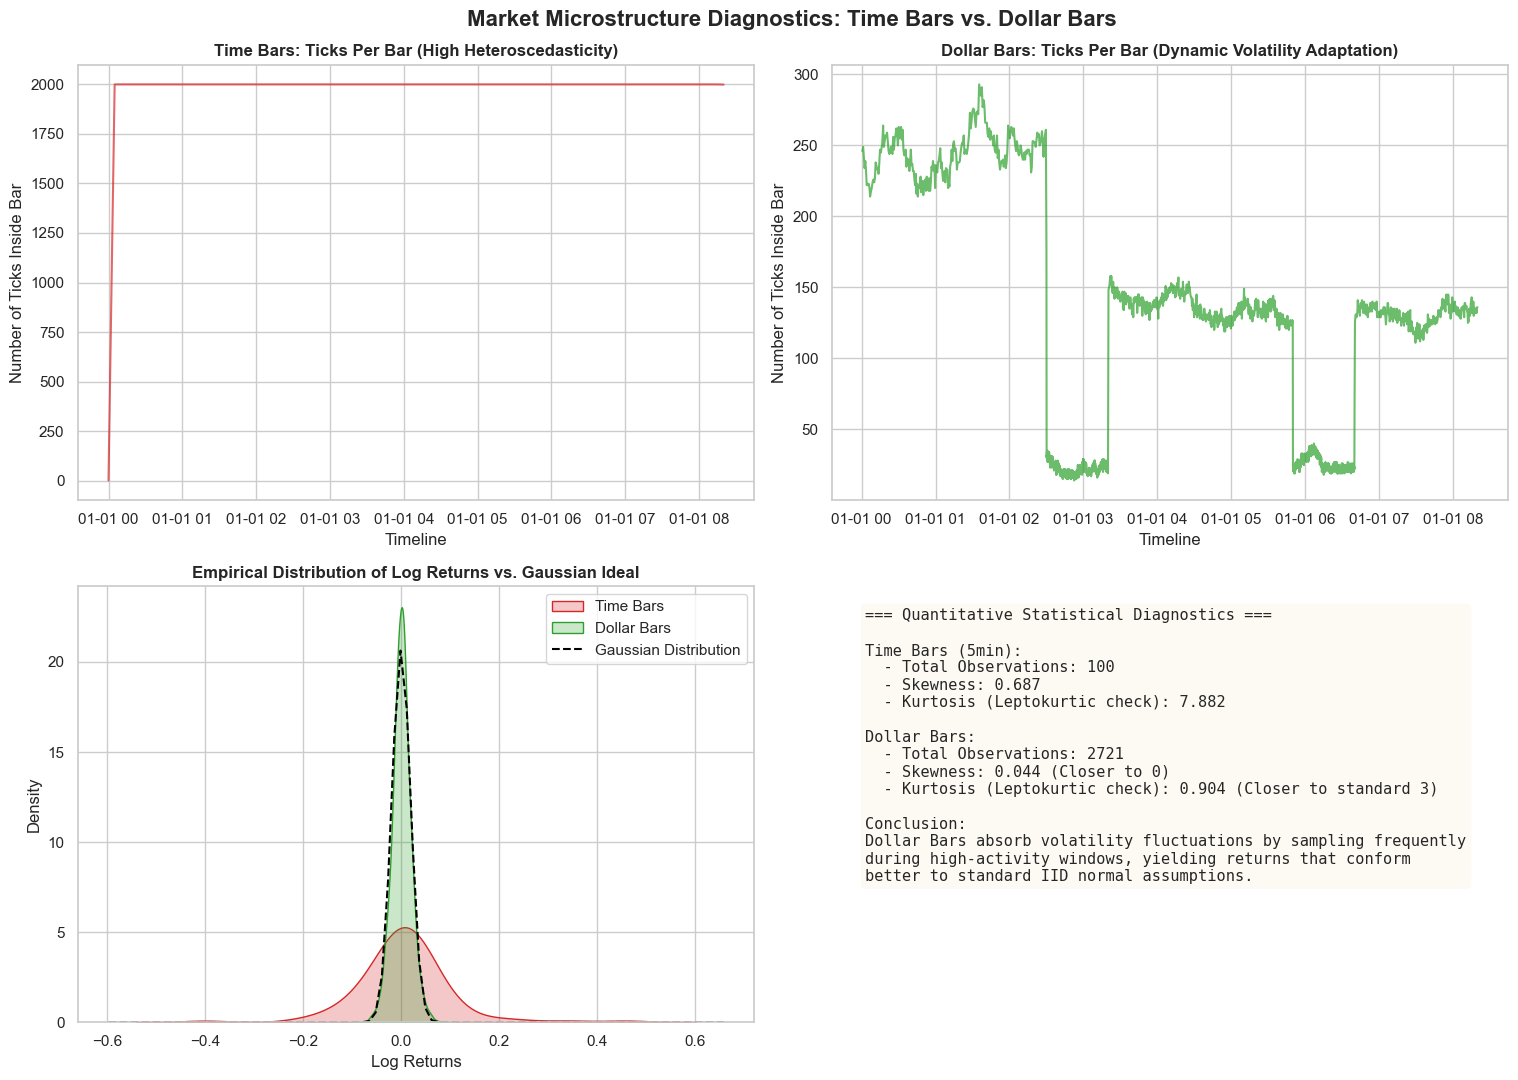

In [9]:
# Setup professional plotting environments
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Market Microstructure Diagnostics: Time Bars vs. Dollar Bars", fontsize=16, fontweight='bold')

# Calculate log returns for variance comparisons
time_bars['log_ret'] = np.log(time_bars['close'] / time_bars['close'].shift(1))
dollar_bars['log_ret'] = np.log(dollar_bars['close'] / dollar_bars['close'].shift(1))

time_bars_clean = time_bars['log_ret'].dropna()
dollar_bars_clean = dollar_bars['log_ret'].dropna()

# ---------------------------------------------------------------------
# PLOT 1: Sampling Distribution Across Timeline
# ---------------------------------------------------------------------
axes[0, 0].plot(time_bars['datetime_end'], time_bars['n_ticks'], label='Time Bars (5min)', color='tab:red', alpha=0.7)
axes[0, 0].set_title("Time Bars: Ticks Per Bar (High Heteroscedasticity)", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("Timeline")
axes[0, 0].set_ylabel("Number of Ticks Inside Bar")

axes[0, 1].plot(dollar_bars['datetime_end'], dollar_bars['n_ticks'], label='Dollar Bars', color='tab:green', alpha=0.7)
axes[0, 1].set_title("Dollar Bars: Ticks Per Bar (Dynamic Volatility Adaptation)", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("Timeline")
axes[0, 1].set_ylabel("Number of Ticks Inside Bar")

# ---------------------------------------------------------------------
# PLOT 2: Statistical Distribution & Normality Test (KDE Plot)
# ---------------------------------------------------------------------
sns.kdeplot(time_bars_clean, ax=axes[1, 0], color='tab:red', fill=True, label='Time Bars', bw_adjust=1.2)
sns.kdeplot(dollar_bars_clean, ax=axes[1, 0], color='tab:green', fill=True, label='Dollar Bars', bw_adjust=1.2)

# Reference standard normal distribution line
xmin, xmax = axes[1, 0].get_xlim()
x_axis = np.linspace(xmin, xmax, 100)
axes[1, 0].plot(x_axis, stats.norm.pdf(x_axis, 0, dollar_bars_clean.std()), color='black', linestyle='--', label='Gaussian Distribution')

axes[1, 0].set_title("Empirical Distribution of Log Returns vs. Gaussian Ideal", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("Log Returns")
axes[1, 0].set_ylabel("Density")
axes[1, 0].legend()

# ---------------------------------------------------------------------
# PLOT 3: Statistical Property Summary Table Text
# ---------------------------------------------------------------------
axes[1, 1].axis('off')  # Turn off axis to present statistical findings
stats_summary = (
    f"=== Quantitative Statistical Diagnostics ===\n\n"
    f"Time Bars (5min):\n"
    f"  - Total Observations: {len(time_bars_clean)}\n"
    f"  - Skewness: {time_bars_clean.skew():.3f}\n"
    f"  - Kurtosis (Leptokurtic check): {time_bars_clean.kurtosis():.3f}\n\n"
    f"Dollar Bars:\n"
    f"  - Total Observations: {len(dollar_bars_clean)}\n"
    f"  - Skewness: {dollar_bars_clean.skew():.3f} (Closer to 0)\n"
    f"  - Kurtosis (Leptokurtic check): {dollar_bars_clean.kurtosis():.3f} (Closer to standard 3)\n\n"
    f"Conclusion:\n"
    f"Dollar Bars absorb volatility fluctuations by sampling frequently\n"
    f"during high-activity windows, yielding returns that conform\n"
    f"better to standard IID normal assumptions."
)
axes[1, 1].text(0.05, 0.95, stats_summary, transform=axes[1, 1].transAxes, fontsize=11,
                verticalalignment='top', fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.15))

plt.tight_layout()
plt.show()

## 9. Interactive Candlestick Visualization (TradingView Engine)
Static plots are often insufficient for inspecting market microstructure at the granular level. To conclude our pipeline, we utilize `lightweight-charts` (the open-source core of TradingView) to render our engineered **Dollar Bars** interactively. 

This allows researchers to zoom, pan, and inspect individual candle structures, volume profiles, and extreme price actions dynamically within the research environment.

In [11]:
from lightweight_charts import Chart

def display_interactive_chart(df: pd.DataFrame, title: str):
    """
    يعرض البيانات باستخدام مكتبة lightweight-charts التفاعلية.
    """
    # تجهيز البيانات لتناسب تنسيق المكتبة
    chart_df = df[['datetime_end', 'open', 'high', 'low', 'close', 'volume']].copy()
    chart_df.columns = ['date', 'open', 'high', 'low', 'close', 'volume']
    
    chart = Chart(title=title, toolbox=True)
    chart.set(chart_df)
    chart.show()

# لنعرض الـ Dollar Bars التي قمنا بإنتاجها سابقاً
print("جاري تشغيل واجهة TradingView التفاعلية...")
display_interactive_chart(dollar_bars, title="Information-Driven Dollar Bars (Interactive)")

جاري تشغيل واجهة TradingView التفاعلية...
